In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, Conv2DTranspose,
                                      BatchNormalization, Activation,
                                      concatenate)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.13.0
GPU: []


In [2]:
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print("✅ Metrics defined")

✅ Metrics defined


In [4]:
import numpy as np
import cv2
from sklearn.model_selection import train_test_split

data = np.load("data/Part 1- Train data - images.npy", allow_pickle=True)
print("Total pairs:", len(data))

IMG_SIZE = 224
images, masks = [], []

for i, pair in enumerate(data):
    try:
        img = np.array(pair[0], dtype=np.float32)
        annotations = pair[1]
        H, W = img.shape[:2]
        mask = np.zeros((H, W), dtype=np.float32)

        for ann in annotations:
            if 'points' not in ann:
                continue
            points = ann['points']
            pts = np.array([
                [int(p['x'] * W), int(p['y'] * H)]
                for p in points
            ], dtype=np.int32)
            if len(pts) >= 3:
                cv2.fillPoly(mask, [pts], 1.0)
            elif len(pts) == 2:
                x1, y1 = pts[0]
                x2, y2 = pts[1]
                x1, x2 = min(x1,x2), max(x1,x2)
                y1, y2 = min(y1,y2), max(y1,y2)
                mask[y1:y2, x1:x2] = 1.0

        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[-1] == 4:
            img = img[:, :, :3]
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        if img.max() > 1.0:
            img = img / 255.0

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 0.5).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    except Exception as e:
        print(f"Skip {i}: {e}")

X = np.array(images, dtype=np.float32)
y = np.array(masks, dtype=np.float32)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print("Data ready!")

Total pairs: 409
X shape: (409, 224, 224, 3)
y shape: (409, 224, 224, 1)
Train: (327, 224, 224, 3), Val: (82, 224, 224, 3)
Data ready!


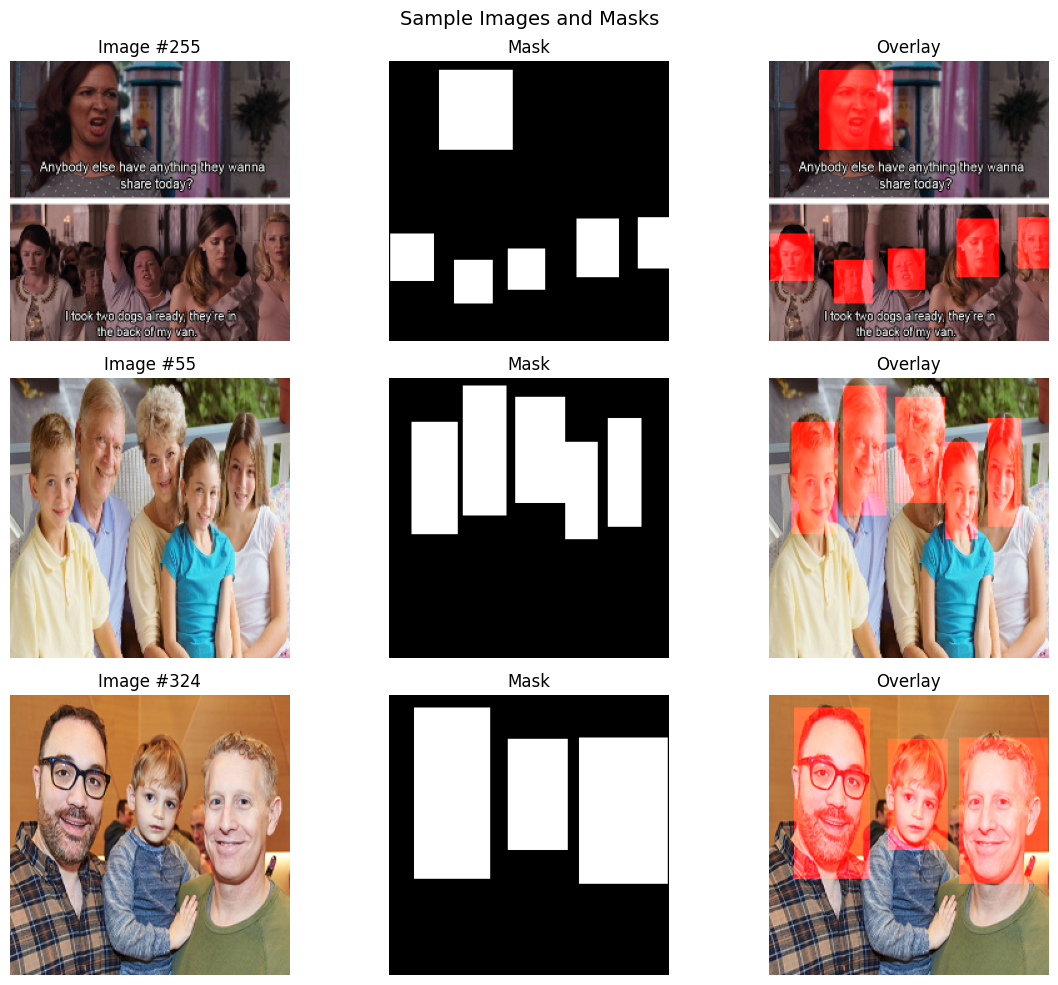

✅ EDA done


In [5]:
#EDA / Visualization

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Sample Images and Masks", fontsize=14)

for i in range(3):
    idx = np.random.randint(0, len(X_train))
    
    axes[i][0].imshow(X_train[idx])
    axes[i][0].set_title(f"Image #{idx}")
    axes[i][0].axis('off')
    
    axes[i][1].imshow(y_train[idx, :, :, 0], cmap='gray')
    axes[i][1].set_title("Mask")
    axes[i][1].axis('off')
    
    # Overlay
    overlay = X_train[idx].copy()
    overlay[:, :, 0] = np.where(y_train[idx, :, :, 0] > 0.5,
                                  1.0, overlay[:, :, 0])
    axes[i][2].imshow(overlay)
    axes[i][2].set_title("Overlay")
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=100)
plt.show()
print("✅ EDA done")

In [6]:
def build_unet(input_shape=(256, 256, 3)):
    # Encoder: MobileNetV2 (pretrained)
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    
    # Skip connection layers
    s1 = base.get_layer('input_1').output          # 256x256
    s2 = base.get_layer('block_1_expand_relu').output   # 128x128
    s3 = base.get_layer('block_3_expand_relu').output   # 64x64
    s4 = base.get_layer('block_6_expand_relu').output   # 32x32
    bridge = base.get_layer('block_13_expand_relu').output  # 16x16
    
    # Decoder
    def decoder_block(x, skip, filters):
        x = Conv2DTranspose(filters, (2,2), strides=2, padding='same')(x)
        x = concatenate([x, skip])
        x = Conv2D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv2D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        return x
    
    d1 = decoder_block(bridge, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)
    
    outputs = Conv2D(1, 1, activation='sigmoid')(d4)
    model = Model(inputs=base.input, outputs=outputs)
    return model

model = build_unet()
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, iou_score]
)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 128, 128, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 128, 128, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 128, 128, 32)         0         ['bn_Conv1[0][0]']        

In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, BatchNormalization, 
                                      Activation, concatenate, UpSampling2D)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

def build_unet(input_shape=(224, 224, 3)):
    base = MobileNetV2(input_shape=input_shape,
                       include_top=False,
                       weights='imagenet')
    base.trainable = False

    # Actual layer names use karo (input_4 nahi — base.input use karo directly)
    s1 = base.input                                          # 224x224
    s2 = base.get_layer('block_1_expand_relu').output       # 112x112
    s3 = base.get_layer('block_3_expand_relu').output       # 56x56
    s4 = base.get_layer('block_6_expand_relu').output       # 28x28
    bridge = base.get_layer('block_13_expand_relu').output  # 14x14

    def decoder_block(x, skip, filters):
        x = UpSampling2D((2, 2))(x)
        x = concatenate([x, skip])
        x = Conv2D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv2D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        return x

    d1 = decoder_block(bridge, s4, 256)
    d2 = decoder_block(d1,     s3, 128)
    d3 = decoder_block(d2,     s2, 64)
    d4 = UpSampling2D((2, 2))(d3)
    d4 = Conv2D(32, 3, padding='same')(d4)
    d4 = BatchNormalization()(d4)
    d4 = Activation('relu')(d4)

    outputs = Conv2D(1, 1, activation='sigmoid')

In [ ]:
#Training
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, concatenate, UpSampling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# ── Metrics ──────────────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# ── Data Loading ──────────────────────────────────────────
IMG_SIZE = 224
data = np.load("data/Part 1- Train data - images.npy", allow_pickle=True)
print("Total pairs:", len(data))

images, masks = [], []
for i, pair in enumerate(data):
    try:
        img  = np.array(pair[0], dtype=np.float32)
        annotations = pair[1]
        H, W = img.shape[:2]
        mask = np.zeros((H, W), dtype=np.float32)

        for ann in annotations:
            if 'points' not in ann:
                continue
            pts = np.array([
                [int(p['x'] * W), int(p['y'] * H)]
                for p in ann['points']
            ], dtype=np.int32)
            if len(pts) >= 3:
                cv2.fillPoly(mask, [pts], 1.0)
            elif len(pts) == 2:
                x1,y1 = pts[0]; x2,y2 = pts[1]
                x1,x2 = min(x1,x2),max(x1,x2)
                y1,y2 = min(y1,y2),max(y1,y2)
                mask[y1:y2, x1:x2] = 1.0

        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[-1] == 4:
            img = img[:,:,:3]
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        if img.max() > 1.0:
            img = img / 255.0

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 0.5).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)
    except Exception as e:
        print(f"Skip {i}: {e}")

X = np.array(images, dtype=np.float32)
y = np.array(masks,  dtype=np.float32)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

# ── Model ─────────────────────────────────────────────────
tf.keras.backend.clear_session()   # purana model clear

base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                   include_top=False, weights='imagenet')
base.trainable = False

s1 = base.input
s2 = base.get_layer('block_1_expand_relu').output
s3 = base.get_layer('block_3_expand_relu').output
s4 = base.get_layer('block_6_expand_relu').output
bridge = base.get_layer('block_13_expand_relu').output

def decoder_block(x, skip, filters):
    x = UpSampling2D((2,2))(x)
    x = concatenate([x, skip])
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

d1 = decoder_block(bridge, s4, 256)
d2 = decoder_block(d1,     s3, 128)
d3 = decoder_block(d2,     s2, 64)
d4 = UpSampling2D((2,2))(d3)
d4 = Conv2D(32, 3, padding='same', activation='relu')(d4)
outputs = Conv2D(1, 1, activation='sigmoid')(d4)

model = Model(inputs=base.input, outputs=outputs)
model.compile(optimizer=Adam(1e-4),
              loss=dice_loss,
              metrics=[dice_coefficient, iou_score])

print(f"Model input:  {model.input_shape}")
print(f"Model output: {model.output_shape}")
print(f"Params: {model.count_params():,}")

# ── Training ──────────────────────────────────────────────
callbacks = [
    ModelCheckpoint('model.h5', monitor='val_dice_coefficient',
                    mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_dice_coefficient', patience=10,
                  mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=callbacks
)
print("Training complete!")

Total pairs: 409
X_train: (327, 224, 224, 3), y_train: (327, 224, 224, 1)
Model input:  (None, 224, 224, 3)
Model output: (None, 224, 224, 1)
Params: 3,772,673
Epoch 1/50
41/41 [==============================] - ETA: 0s - loss: 0.6233 - dice_coefficient: 0.3775 - iou_score: 0.3292
Epoch 1: val_dice_coefficient improved from -inf to 0.42207, saving model to model.h5


d:\project\face segmentation\freshenv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


41/41 [==============================] - 105s 2s/step - loss: 0.6233 - dice_coefficient: 0.3775 - iou_score: 0.3292 - val_loss: 0.5882 - val_dice_coefficient: 0.4221 - val_iou_score: 0.3242 - lr: 1.0000e-04
Epoch 2/50
41/41 [==============================] - ETA: 0s - loss: 0.3868 - dice_coefficient: 0.6136 - iou_score: 0.5233
Epoch 2: val_dice_coefficient improved from 0.42207 to 0.54371, saving model to model.h5
41/41 [==============================] - 100s 2s/step - loss: 0.3868 - dice_coefficient: 0.6136 - iou_score: 0.5233 - val_loss: 0.4680 - val_dice_coefficient: 0.5437 - val_iou_score: 0.4610 - lr: 1.0000e-04
Epoch 3/50
41/41 [==============================] - ETA: 0s - loss: 0.3061 - dice_coefficient: 0.6941 - iou_score: 0.5591
Epoch 3: val_dice_coefficient improved from 0.54371 to 0.60160, saving model to model.h5
41/41 [==============================] - 112s 3s/step - loss: 0.3061 - dice_coefficient: 0.6941 - iou_score: 0.5591 - val_loss: 0.3959 - val_dice_coefficient: 0.601

In [ ]:
#Training Curves

from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping, 
                                         ReduceLROnPlateau)

callbacks = [
    ModelCheckpoint(
        'model.h5',
        monitor='val_dice_coefficient',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_dice_coefficient',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=callbacks
)
print("Training complete!")
axes[2].set_title('IoU Score')
axes[2].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()
print("✅ Curves saved")

Epoch 1/50
41/41 [==============================] - ETA: 0s - loss: 0.5968 - dice_coefficient: 0.4038 - iou_score: 0.3434
Epoch 1: val_dice_coefficient improved from -inf to 0.32752, saving model to model.h5
41/41 [==============================] - 192s 5s/step - loss: 0.5968 - dice_coefficient: 0.4038 - iou_score: 0.3434 - val_loss: 0.6804 - val_dice_coefficient: 0.3275 - val_iou_score: 0.2150 - lr: 1.0000e-04
Epoch 2/50
41/41 [==============================] - ETA: 0s - loss: 0.3779 - dice_coefficient: 0.6221 - iou_score: 0.5288
Epoch 2: val_dice_coefficient improved from 0.32752 to 0.61746, saving model to model.h5
41/41 [==============================] - 207s 5s/step - loss: 0.3779 - dice_coefficient: 0.6221 - iou_score: 0.5288 - val_loss: 0.3919 - val_dice_coefficient: 0.6175 - val_iou_score: 0.5269 - lr: 1.0000e-04
Epoch 3/50
41/41 [==============================] - ETA: 0s - loss: 0.3083 - dice_coefficient: 0.6917 - iou_score: 0.5557
Epoch 3: val_dice_coefficient improved from 0

AttributeError: 'numpy.ndarray' object has no attribute 'set_title'

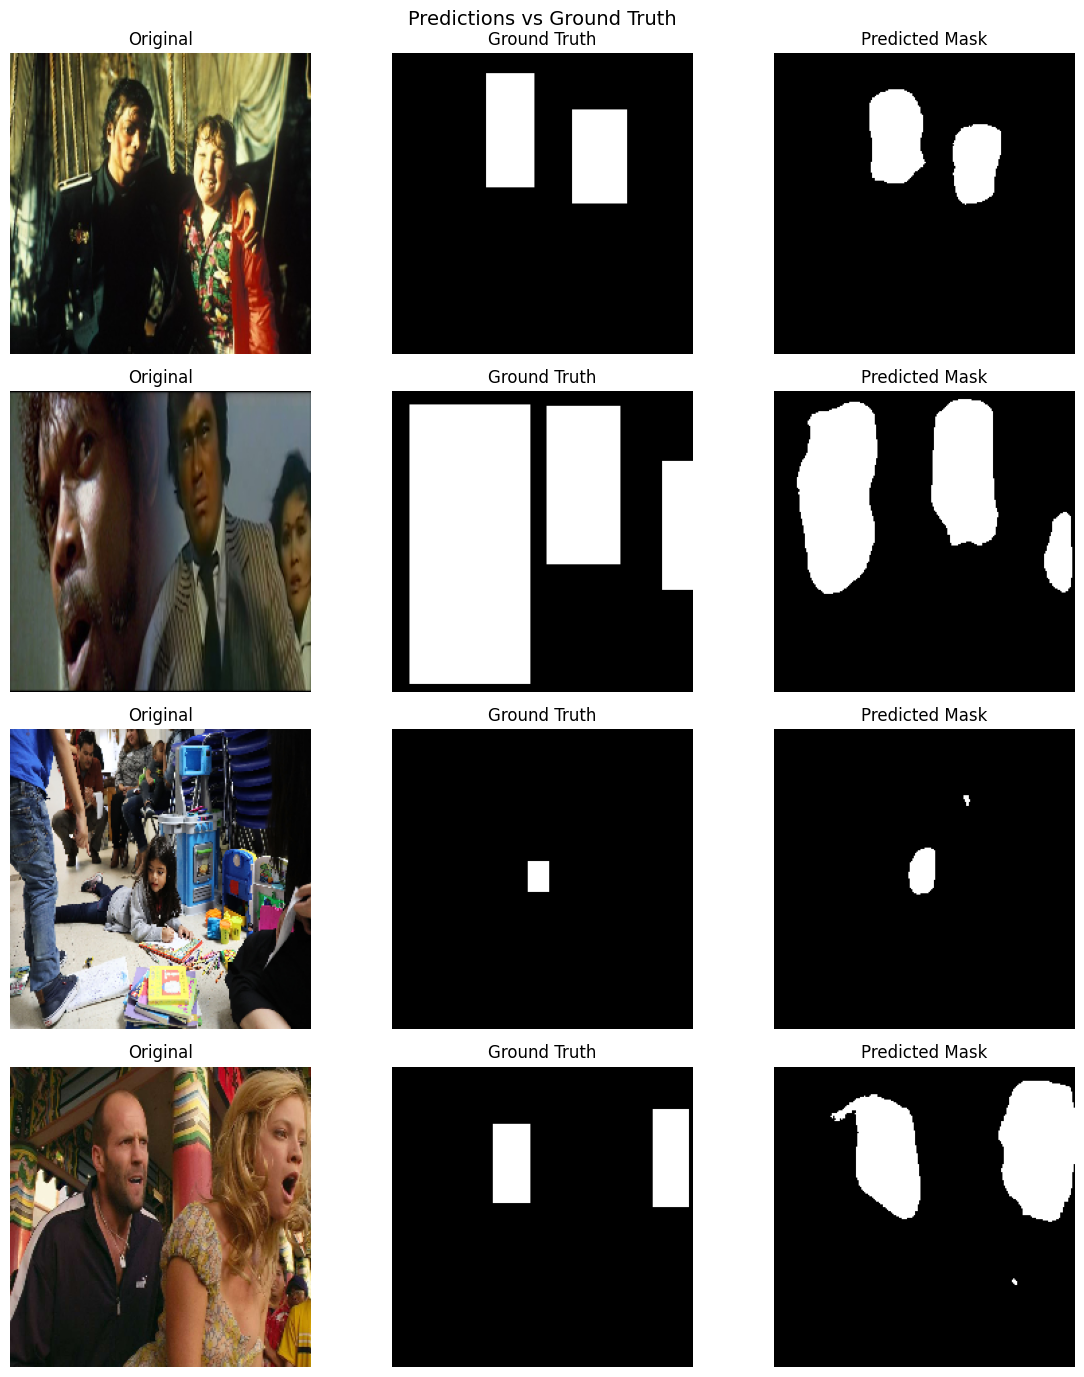

Predictions saved!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
fig.suptitle("Predictions vs Ground Truth", fontsize=14)

for i in range(4):
    idx = np.random.randint(0, len(X_val))
    pred = model.predict(X_val[idx:idx+1], verbose=0)
    pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)

    axes[i][0].imshow(X_val[idx])
    axes[i][0].set_title("Original")
    axes[i][0].axis('off')

    axes[i][1].imshow(y_val[idx, :, :, 0], cmap='gray')
    axes[i][1].set_title("Ground Truth")
    axes[i][1].axis('off')

    axes[i][2].imshow(pred_mask, cmap='gray')
    axes[i][2].set_title("Predicted Mask")
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig("predictions.png")
plt.show()
print("Predictions saved!")

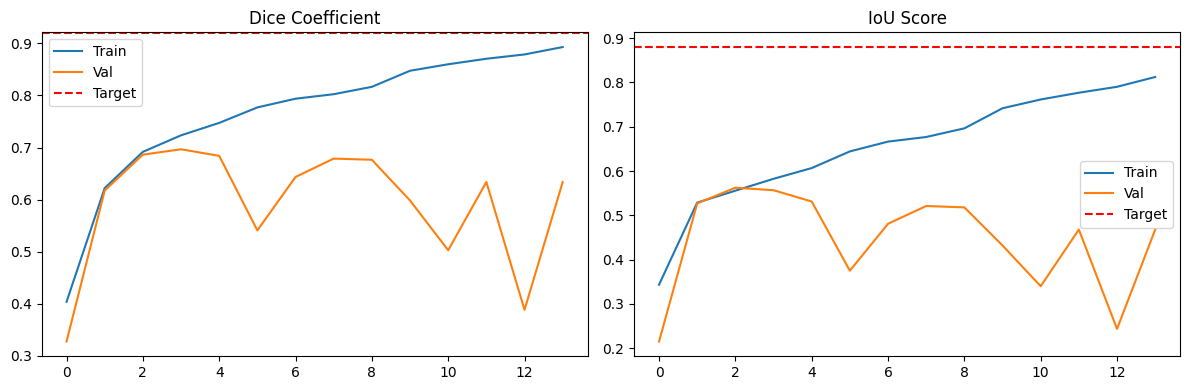

In [ ]:
#Training curves:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['dice_coefficient'], label='Train')
axes[0].plot(history.history['val_dice_coefficient'], label='Val')
axes[0].axhline(0.92, color='red', linestyle='--', label='Target')
axes[0].set_title('Dice Coefficient')
axes[0].legend()

axes[1].plot(history.history['iou_score'], label='Train')
axes[1].plot(history.history['val_iou_score'], label='Val')
axes[1].axhline(0.88, color='red', linestyle='--', label='Target')
axes[1].set_title('IoU Score')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [ ]:
# Evaluation:
from sklearn.metrics import f1_score
import time

results = model.evaluate(X_val, y_val, verbose=0)
print(f"Dice : {results[1]:.4f}")
print(f"IoU  : {results[2]:.4f}")

preds = model.predict(X_val, verbose=0)
f1 = f1_score(y_val.flatten().astype(int),
              (preds > 0.5).flatten().astype(int))
print(f"F1   : {f1:.4f}")

start = time.time()
model.predict(X_val[:10], verbose=0)
ms = (time.time()-start)/10*1000
print(f"Speed: {ms:.1f} ms/image")

Dice : 0.7019
IoU  : 0.5597
F1   : 0.7201
Speed: 120.7 ms/image
